# Risk Classifier for ICU admission and High Risk(Fatality) patient Prediction For COVID-19 Patients
## Team Details
- Neel Chandhrakar, PES2UG24CS310
- Neeraj R Rugi, PES2UG24CS311

## Dataset Used
[COVID-19 Mexico Patient Health Dataset](https://www.kaggle.com/datasets/riteshahlawat/covid19-mexico-patient-health-dataset)

Source: Kaggle, Open License for Educational Use




In [1]:
import pandas as pd


# Steps for Data Processing
The dataset that we have taken has 20 columns. Of which few do not hold relevance to the concerned outcome. 

The Following Steps are taken to standardise the dataset to the given problem:
- All data columns are of type boolean. The original dataset uses the same methodology.
- Age data column is the only data column that is numerical.
- Only Those Rows whose Outcome Column is 1(CoVID 19 Positive) is kept.
- Columns used to predict if patient is at risk of being admitted into the Critical Care Unit:
    * Age (Numerical, Standardised)
    * pneumonia
    * Diabetes
    * COPD(Chronic Obstructive Pulmonary Disease)
    * Asthma
    * Immunosppression
    * Hypertension
    * Cardiovascular
    * Smoker
    * Gender
    * Obesity
- The above deatils are asumed to be known at the time of admission. The Paper provided makes such assumptions too.



In [2]:
raw_data = pd.read_csv("./patient.csv")
# print("Data Columns:\n", raw_data.head())

# Dropping all rows where Outcome != 1
filtered_data = raw_data[raw_data['outcome'] == 1]
# filtered_data = raw_data.copy()
print("After Pre-Filtering Irrlevant Patients:\n",filtered_data.count())

After Pre-Filtering Irrlevant Patients:
 sex                       23471
patient_type              23471
intubated                 23471
pneumonia                 23471
age                       23471
pregnant                  23471
diabetes                  23471
copd                      23471
asthma                    23471
immunosuppression         23471
hypertension              23471
other_diseases            23471
cardiovascular            23471
obesity                   23471
chronic_kidney_failure    23471
smoker                    23471
another_case              23471
outcome                   23471
icu                       23471
death_date                23471
dtype: int64


After Filtering Patients Not Positive for Covid-19, We are left with a sample of size n=23466

A standard split of 80-20 will be used to train and test the model.
* Train Dataset n=18772
* Test Dataset n=4694

In [3]:
filtered_data = filtered_data[['age', 'pneumonia', 
                               'diabetes', 'copd', 'asthma', 'immunosuppression', 
                               'hypertension', 'cardiovascular', 'smoker',
                               'intubated', 'icu', 'death_date', 'sex', 'obesity']]
filtered_data = filtered_data.rename(columns={'age': 'Age', 'sex':'Gender' ,'pneumonia': 'Has_Pneumonia',
                                              'diabetes': 'Has_Diabetes', 'copd': 'Has_COPD',
                                              'asthma': 'Has_Asthma', 'immunosuppression': 'Is_Immunosuppressed',
                                              'hypertension': 'Has_Hypertension', 'cardiovascular': 'Has_Cardiovascular',
                                              'smoker': 'Is_Smoker','obesity':'Is_Obese', 'intubated': 'Is_Intubated', 
                                              'icu': 'Admitted_ICU', 'death_date': 'Is_Deceased'})

cat_cols = ['Has_Pneumonia', 'Has_Diabetes', 'Has_COPD', 'Has_Asthma',
            'Is_Immunosuppressed', 'Has_Hypertension', 'Has_Cardiovascular',
            'Is_Smoker', 'Is_Intubated', 'Admitted_ICU', 'Gender', 'Is_Obese']

before = len(filtered_data)
filtered_data = filtered_data[~filtered_data[cat_cols].eq(99).any(axis=1)]
print(f"Dropped {before - len(filtered_data)} rows ({(before - len(filtered_data)) / before:.2%})")
print(filtered_data[cat_cols].isin([97, 98]).sum())

filtered_data['Has_Pneumonia'] = (filtered_data['Has_Pneumonia'] == 1).astype(int)
filtered_data['Has_Diabetes'] = (filtered_data['Has_Diabetes'] == 1).astype(int)
filtered_data['Has_COPD'] = (filtered_data['Has_COPD'] == 1).astype(int)
filtered_data['Has_Asthma'] = (filtered_data['Has_Asthma'] == 1).astype(int)
filtered_data['Is_Immunosuppressed'] = (filtered_data['Is_Immunosuppressed'] == 1).astype(int)
filtered_data['Has_Hypertension'] = (filtered_data['Has_Hypertension'] == 1).astype(int)
filtered_data['Has_Cardiovascular'] = (filtered_data['Has_Cardiovascular'] == 1).astype(int)
filtered_data['Is_Smoker'] = (filtered_data['Is_Smoker'] == 1).astype(int)
filtered_data['Admitted_ICU'] = (filtered_data['Admitted_ICU'] == 1).astype(int)
filtered_data['Is_Intubated'] = (filtered_data['Is_Intubated'] == 1).astype(int)
filtered_data['Gender'] = (filtered_data['Gender'] == 1).astype(int)
filtered_data['Is_Obese'] = (filtered_data['Is_Obese'] == 1).astype(int)
filtered_data['Is_Deceased'] = (filtered_data['Is_Deceased'] != '9999-99-99').astype(int)
# filtered_data.head()

for col in filtered_data.columns:
    print(f"\n--- {col} ---")
    print(filtered_data[col].value_counts())
    
filtered_data.head()
filtered_data.to_csv("./InputData.csv", index=False)

Dropped 6 rows (0.03%)
Has_Pneumonia              0
Has_Diabetes             236
Has_COPD                 238
Has_Asthma               246
Is_Immunosuppressed      241
Has_Hypertension         235
Has_Cardiovascular       245
Is_Smoker                236
Is_Intubated           14200
Admitted_ICU           14200
Gender                     0
Is_Obese                 229
dtype: int64

--- Age ---
Age
47     580
49     579
46     575
45     570
52     563
      ... 
99       2
96       2
102      1
113      1
98       1
Name: count, Length: 103, dtype: int64

--- Has_Pneumonia ---
Has_Pneumonia
0    16585
1     6880
Name: count, dtype: int64

--- Has_Diabetes ---
Has_Diabetes
0    19119
1     4346
Name: count, dtype: int64

--- Has_COPD ---
Has_COPD
0    22888
1      577
Name: count, dtype: int64

--- Has_Asthma ---
Has_Asthma
0    22685
1      780
Name: count, dtype: int64

--- Is_Immunosuppressed ---
Is_Immunosuppressed
0    23037
1      428
Name: count, dtype: int64

--- Has_Hypertensio

# Final Data Interpretation
Only 6 Rows exist that contain missing data, that is 0.03% of the dataset. And is hence negligble and dropped.
The dataset contains 99/98 values for `Not Applicable` columns, this is used to indicate outpatient department and is set to false. Doing so should be a safe assumption as being not intubated in outpatient is same as that of being admitted, the difference comes down to how the dataset was structured to be viewed from the prespective of admission and not as a general overlook.

In [4]:
# Creating separate dataframes for input and output variables
INPUT_DATA = filtered_data[['Age', 'Has_Pneumonia', 'Has_Diabetes', 'Has_COPD', 'Has_Asthma',
                            'Is_Immunosuppressed', 'Has_Hypertension', 
                            'Has_Cardiovascular', 'Is_Smoker', 'Gender', 'Is_Obese']]

ICU_DATA = filtered_data[['Admitted_ICU']]
INTUBATED_DATA = filtered_data[['Is_Intubated']]
DEATH_DATA = filtered_data[['Is_Deceased']]


# Algorithim Development
Each Model will have 3 sub-models for the Binary Classification task of predicting wheather:
 * Patient is at Risk Of Intubation (Yes/No)
 * Patient At Risk of Being Admitted to ICU/ Patient Should Be Admitted to ICU (Yes/No)
 * Patient At Risk Of Fatality (Yes/No)

Since All 3 are Binary Classification Problems, We will Use Standard Supervised Learning Algorithms for the task and compare their Performances.
Models Choosen:
- Logistic Regression
- SVM
- Decision Trees

# Model 1: Logistic Regression

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Splitting the data into training and testing sets
X_ICU_train, X_ICU_test, y_ICU_train, y_ICU_test = train_test_split(
    INPUT_DATA, ICU_DATA, test_size=0.2, random_state=42)

X_INT_train, X_INT_test, y_INT_train, y_INT_test = train_test_split(
    INPUT_DATA, INTUBATED_DATA, test_size=0.2, random_state=42)

X_DEATH_train, X_DEATH_test, y_DEATH_train, y_DEATH_test = train_test_split(
    INPUT_DATA, DEATH_DATA, test_size=0.2, random_state=42)

# Creating a pipeline for preprocessing and model training
numeric_features = ['Age']
scaled_pre = ColumnTransformer(
    [("num", StandardScaler(), numeric_features)],
    remainder="passthrough"
)

ICU_model = Pipeline([
    ("pre", scaled_pre),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")) #handle class imbalance
])

INT_model = Pipeline([
    ("pre", scaled_pre),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")) #handle class imbalance
])

DEATH_model = Pipeline([
    ("pre", scaled_pre),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))#handle class imbalance
])

# Training the model for ICU prediction
ICU_model.fit(X_ICU_train, y_ICU_train)
# Training the model for Intubation prediction
INT_model.fit(X_INT_train, y_INT_train)
# Training the model for Death prediction
DEATH_model.fit(X_DEATH_train, y_DEATH_train)




/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Has_Pneumonia','Has_Diabetes',...,'Is_Smoker','Gender','Is_Obese']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns that


 ************************* Results for ICU Prediction Model*************************
              precision    recall  f1-score   support

           0       0.99      0.74      0.84      4495
           1       0.12      0.84      0.21       198

    accuracy                           0.74      4693
   macro avg       0.56      0.79      0.53      4693
weighted avg       0.95      0.74      0.82      4693

ROC AUC: 0.829


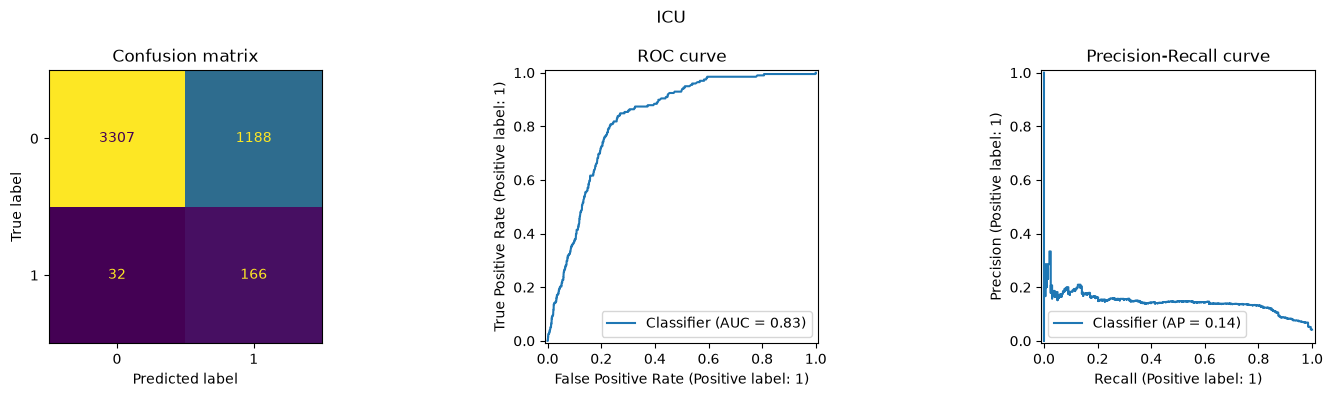


 ************************* Results for Intubation Prediction Model*************************
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      4498
           1       0.14      0.94      0.24       195

    accuracy                           0.75      4693
   macro avg       0.57      0.84      0.54      4693
weighted avg       0.96      0.75      0.82      4693

ROC AUC: 0.877


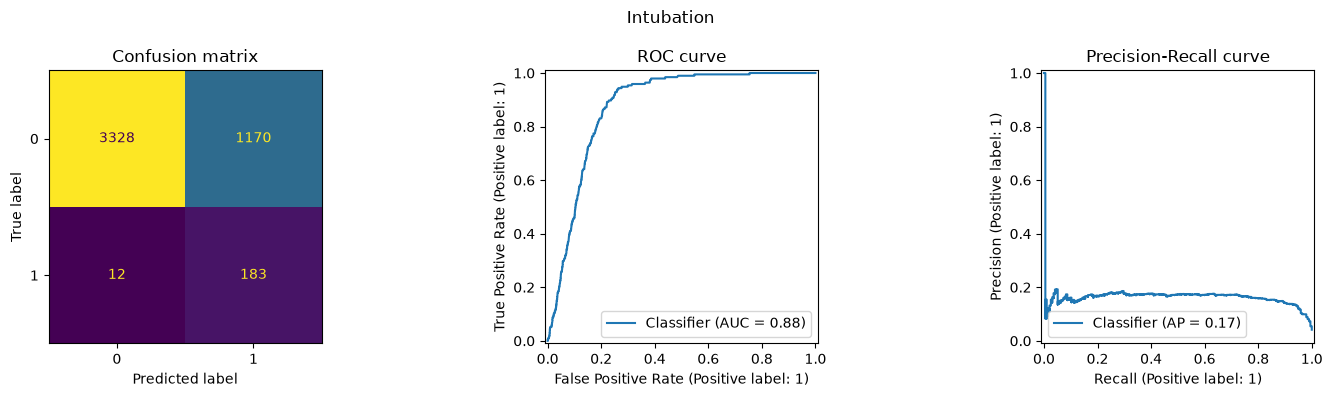


 ************************* Results for Death Prediction Model*************************
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      4266
           1       0.25      0.80      0.38       427

    accuracy                           0.76      4693
   macro avg       0.61      0.78      0.61      4693
weighted avg       0.91      0.76      0.81      4693

ROC AUC: 0.848


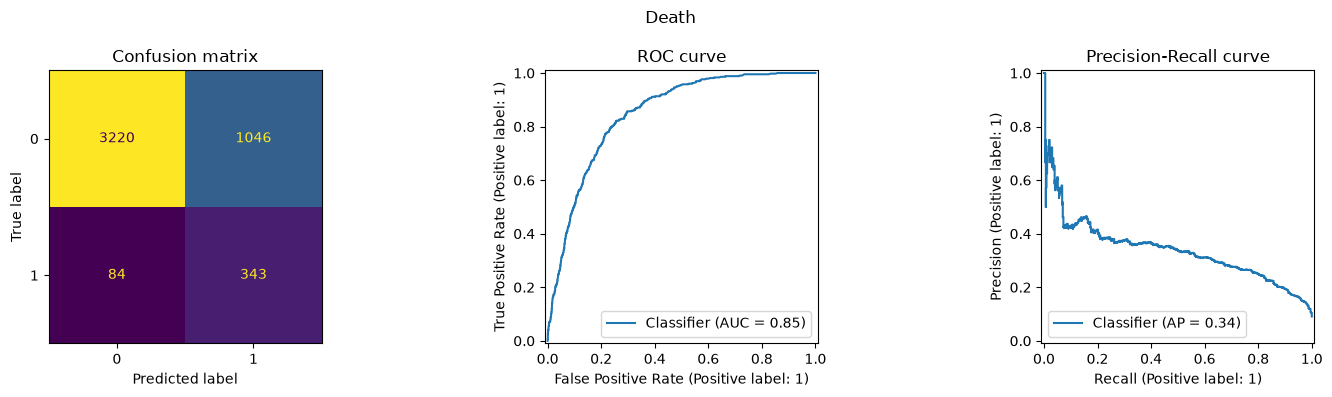

In [6]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n {'*'*25} Results for {name} Prediction Model{'*'*25}")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], colorbar=False)
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
    ax[0].set_title("Confusion matrix")
    ax[1].set_title("ROC curve")
    ax[2].set_title("Precision-Recall curve")
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

evaluate(ICU_model,   X_ICU_test,   y_ICU_test,   "ICU")
evaluate(INT_model,   X_INT_test,   y_INT_test,   "Intubation")
evaluate(DEATH_model, X_DEATH_test, y_DEATH_test, "Death")

In [7]:
import joblib
joblib.dump(ICU_model, "./Models/LR_ICU_model.joblib")
joblib.dump(INT_model, "./Models/LR_INT_model.joblib")
joblib.dump(DEATH_model, "./Models/LR_DEATH_model.joblib")

print(INPUT_DATA.columns)
print("-"*15)
print("ICU Weights:", ICU_model['clf'].coef_)
print("ICU Bias:", ICU_model['clf'].intercept_)
print("-"*15)
print("INTUBATION Weights:", INT_model['clf'].coef_)
print("INTUBATION Bias:", INT_model['clf'].intercept_)
print("-"*15)
print("DEATH Weights:", DEATH_model['clf'].coef_)
print("DEATH Bias:", DEATH_model['clf'].intercept_)

Index(['Age', 'Has_Pneumonia', 'Has_Diabetes', 'Has_COPD', 'Has_Asthma',
       'Is_Immunosuppressed', 'Has_Hypertension', 'Has_Cardiovascular',
       'Is_Smoker', 'Gender', 'Is_Obese'],
      dtype='str')
---------------
ICU Weights: [[ 0.27982764  2.92462387  0.11906054 -0.20632713  0.47295659  0.28485192
   0.13455293 -0.09182644 -0.21316822 -0.44220437  0.29410491]]
ICU Bias: [-1.86554072]
---------------
INTUBATION Weights: [[ 0.32941222  3.78050736  0.09581416  0.01089887 -0.36247341  0.12539123
   0.09488621  0.03177091  0.07945343 -0.36648034  0.41096438]]
INTUBATION Bias: [-2.73703161]
---------------
DEATH Weights: [[ 0.73054459  1.81599347  0.54661573  0.33189057  0.03675812  0.69493621
   0.34633505  0.07303732 -0.38522335 -0.56107225  0.50769144]]
DEATH Bias: [-1.37380889]


# Model 2: SVM

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Splitting the data into training and testing sets
X_ICU_train, X_ICU_test, y_ICU_train, y_ICU_test = train_test_split(
    INPUT_DATA, ICU_DATA, test_size=0.2, random_state=42)

X_INT_train, X_INT_test, y_INT_train, y_INT_test = train_test_split(
    INPUT_DATA, INTUBATED_DATA, test_size=0.2, random_state=42)

X_DEATH_train, X_DEATH_test, y_DEATH_train, y_DEATH_test = train_test_split(
    INPUT_DATA, DEATH_DATA, test_size=0.2, random_state=42)


num_cols = ['Age']
scaled_svm_pre = preprocess = ColumnTransformer(
    [("num", StandardScaler(), num_cols)],
    remainder="passthrough",
)

ICU_model = Pipeline([
    ("pre", scaled_svm_pre),
    ("clf", SVC(probability=False, class_weight="balanced", kernel="rbf")) #handle class imbalance
])

INT_model = Pipeline([
    ("pre", scaled_svm_pre),
    ("clf", SVC(probability=False, class_weight="balanced", kernel="rbf")) #handle class imbalance
])

DEATH_model = Pipeline([
    ("pre", scaled_svm_pre),
    ("clf", SVC(probability=False, class_weight="balanced", kernel="rbf")) #handle class imbalance
])  

# Training the model for ICU prediction
ICU_model.fit(X_ICU_train, y_ICU_train)
# Training the model for Intubation prediction
INT_model.fit(X_INT_train, y_INT_train)
# Training the model for Death prediction
DEATH_model.fit(X_DEATH_train, y_DEATH_train)




/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/media/neeraj-r-rugi/NEERAJ-DRIVE/BOJ_Problems/ML/.venv/lib/python3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Has_Pneumonia','Has_Diabetes',...,'Is_Smoker','Gender','Is_Obese']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns that


 ************************* Results for ICU Prediction Model *************************
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      4495
           1       0.12      0.82      0.21       198

    accuracy                           0.74      4693
   macro avg       0.56      0.78      0.53      4693
weighted avg       0.95      0.74      0.82      4693

ROC AUC: 0.802
Average precision (PR AUC): 0.135 (random baseline ~ 0.042)
Precision at recall >= 0.8: 0.126
Precision at recall >= 0.9: 0.088
Precision at recall >= 0.95: 0.050


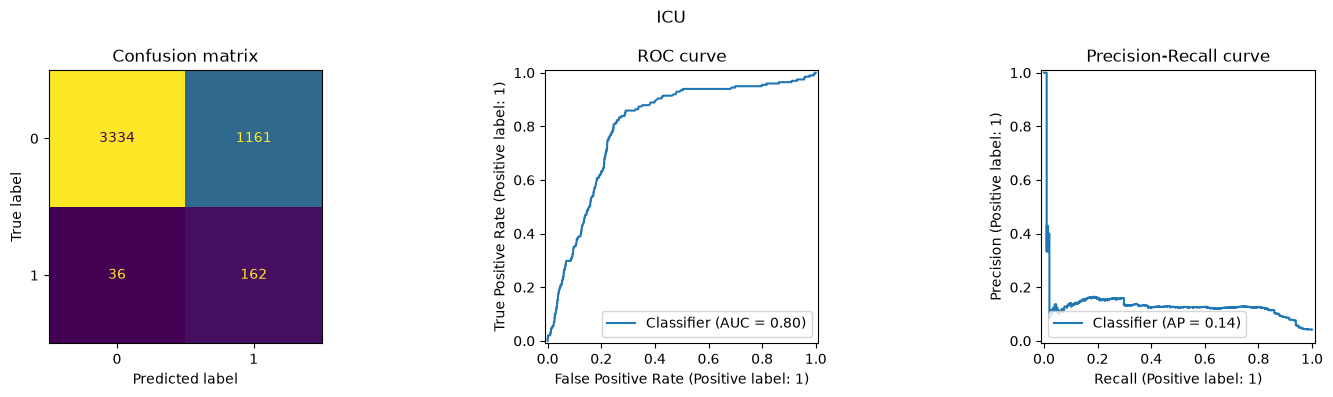


 ************************* Results for Intubation Prediction Model *************************
              precision    recall  f1-score   support

           0       1.00      0.75      0.86      4498
           1       0.14      0.92      0.24       195

    accuracy                           0.76      4693
   macro avg       0.57      0.83      0.55      4693
weighted avg       0.96      0.76      0.83      4693

ROC AUC: 0.846
Average precision (PR AUC): 0.141 (random baseline ~ 0.042)
Precision at recall >= 0.8: 0.138
Precision at recall >= 0.9: 0.138
Precision at recall >= 0.95: 0.111


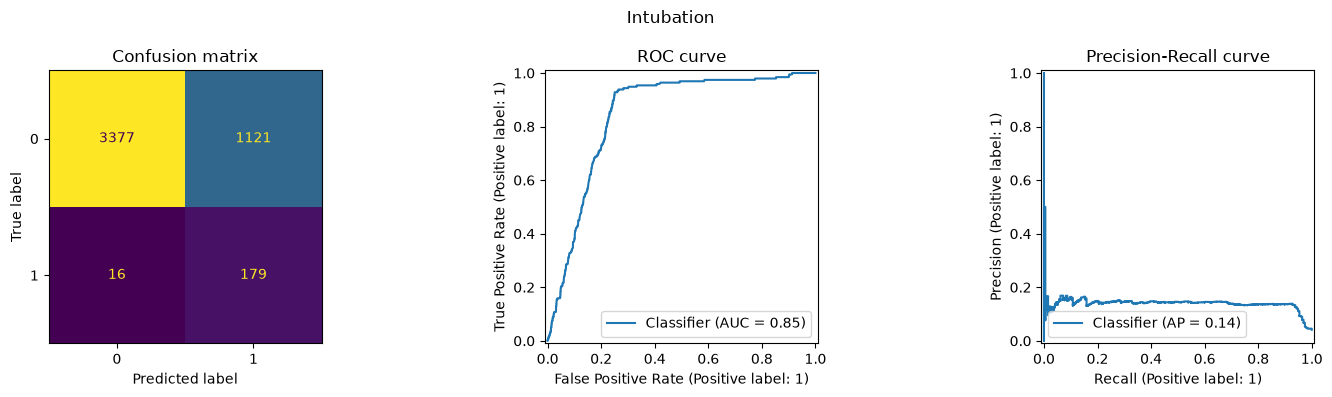


 ************************* Results for Death Prediction Model *************************
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      4266
           1       0.23      0.83      0.37       427

    accuracy                           0.74      4693
   macro avg       0.61      0.78      0.60      4693
weighted avg       0.91      0.74      0.79      4693

ROC AUC: 0.811
Average precision (PR AUC): 0.25 (random baseline ~ 0.091)
Precision at recall >= 0.8: 0.246
Precision at recall >= 0.9: 0.196
Precision at recall >= 0.95: 0.109


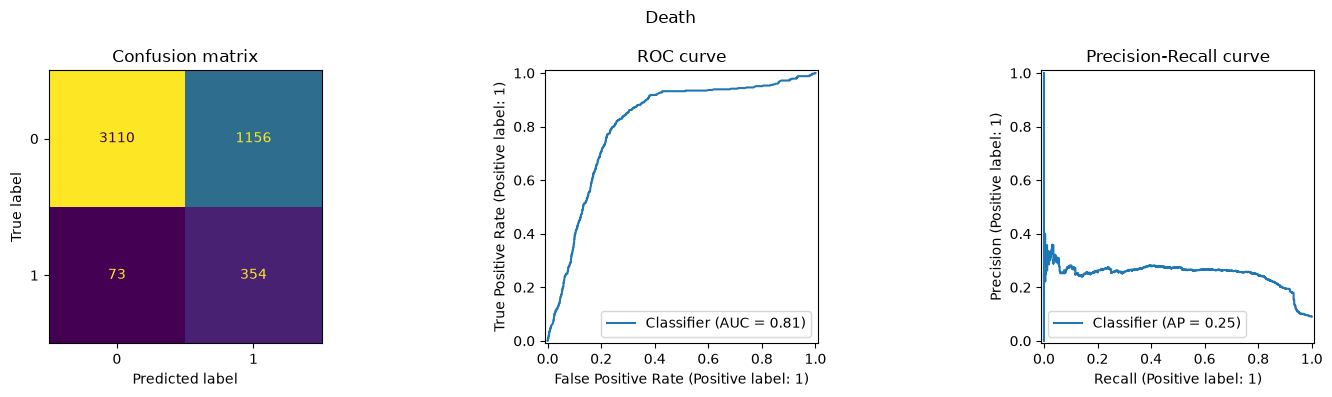

In [9]:
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import numpy as np


def precision_at_recall(y_true, scores, targets=(0.8, 0.9, 0.95)):
    """Best precision achievable while keeping recall >= each target."""
    precision, recall, _ = precision_recall_curve(y_true, scores)
    out = {}
    for t in targets:
        mask = recall >= t
        out[t] = precision[mask].max() if mask.any() else float("nan")
    return out


def evaluate(model, X_test, y_test, name):
    y_test = np.asarray(y_test).ravel()
    y_pred = model.predict(X_test)
    # SVC(probability=False) has no predict_proba; decision_function gives a
    # continuous score (higher = more likely positive) that works for ROC/PR.
    y_score = model.decision_function(X_test)

    print(f"\n {'*'*25} Results for {name} Prediction Model {'*'*25}")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", round(roc_auc_score(y_test, y_score), 3))
    print("Average precision (PR AUC):", round(average_precision_score(y_test, y_score), 3),
          f"(random baseline ~ {y_test.mean():.3f})")
    for t, p in precision_at_recall(y_test, y_score).items():
        print(f"Precision at recall >= {t}: {p:.3f}")

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], colorbar=False)
    RocCurveDisplay.from_predictions(y_test, y_score, ax=ax[1])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax[2])
    ax[0].set_title("Confusion matrix")
    ax[1].set_title("ROC curve")
    ax[2].set_title("Precision-Recall curve")
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


evaluate(ICU_model,   X_ICU_test,   y_ICU_test,   "ICU")
evaluate(INT_model,   X_INT_test,   y_INT_test,   "Intubation")
evaluate(DEATH_model, X_DEATH_test, y_DEATH_test, "Death")

# Model 3: Decision Trees

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Splitting the data into training and testing sets (same as before)
X_ICU_train, X_ICU_test, y_ICU_train, y_ICU_test = train_test_split(
    INPUT_DATA, ICU_DATA, test_size=0.2, random_state=42)

X_INT_train, X_INT_test, y_INT_train, y_INT_test = train_test_split(
    INPUT_DATA, INTUBATED_DATA, test_size=0.2, random_state=42)

X_DEATH_train, X_DEATH_test, y_DEATH_train, y_DEATH_test = train_test_split(
    INPUT_DATA, DEATH_DATA, test_size=0.2, random_state=42)

def make_tree():
    return DecisionTreeClassifier(
        max_depth=6,            # limits tree size so it doesn't Overfit
        min_samples_leaf=50,    # each leaf must cover enough patients to give a stable estimate
        class_weight="balanced",  # handle class imbalance
        random_state=42,
    )

ICU_model = make_tree()
INT_model = make_tree()
DEATH_model = make_tree()

ICU_model.fit(X_ICU_train, y_ICU_train)
INT_model.fit(X_INT_train, y_INT_train)
DEATH_model.fit(X_DEATH_train, y_DEATH_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_fea


 ************************* Results for ICU Prediction Model *************************
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      4495
           1       0.12      0.83      0.21       198

    accuracy                           0.74      4693
   macro avg       0.56      0.78      0.53      4693
weighted avg       0.95      0.74      0.81      4693

ROC AUC: 0.83
Average precision (PR AUC): 0.134 (random baseline ~ 0.042)
Precision at recall >= 0.8: 0.124
Precision at recall >= 0.9: 0.095
Precision at recall >= 0.95: 0.076


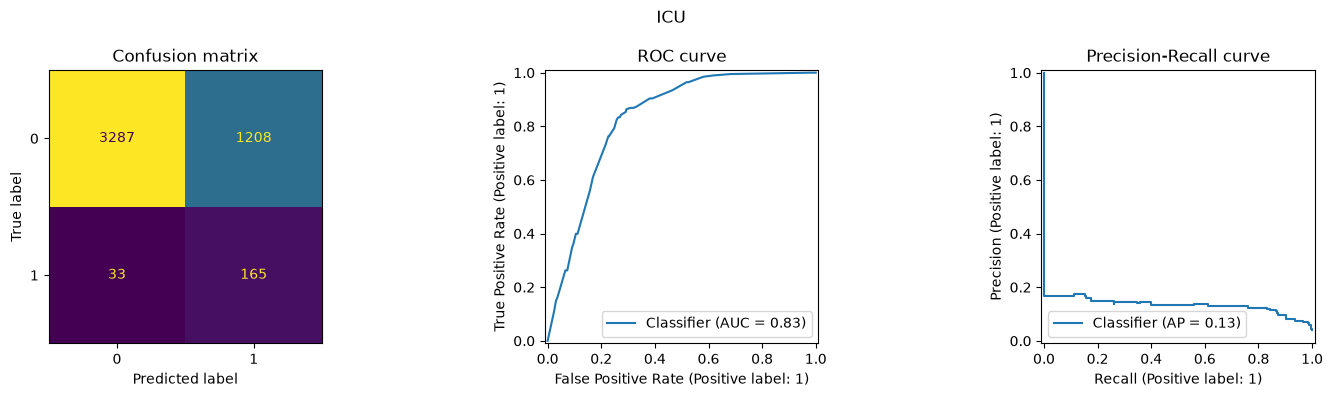


 ************************* Results for Intubation Prediction Model *************************
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      4498
           1       0.13      0.90      0.23       195

    accuracy                           0.75      4693
   macro avg       0.56      0.82      0.54      4693
weighted avg       0.96      0.75      0.82      4693

ROC AUC: 0.852
Average precision (PR AUC): 0.15 (random baseline ~ 0.042)
Precision at recall >= 0.8: 0.144
Precision at recall >= 0.9: 0.132
Precision at recall >= 0.95: 0.091


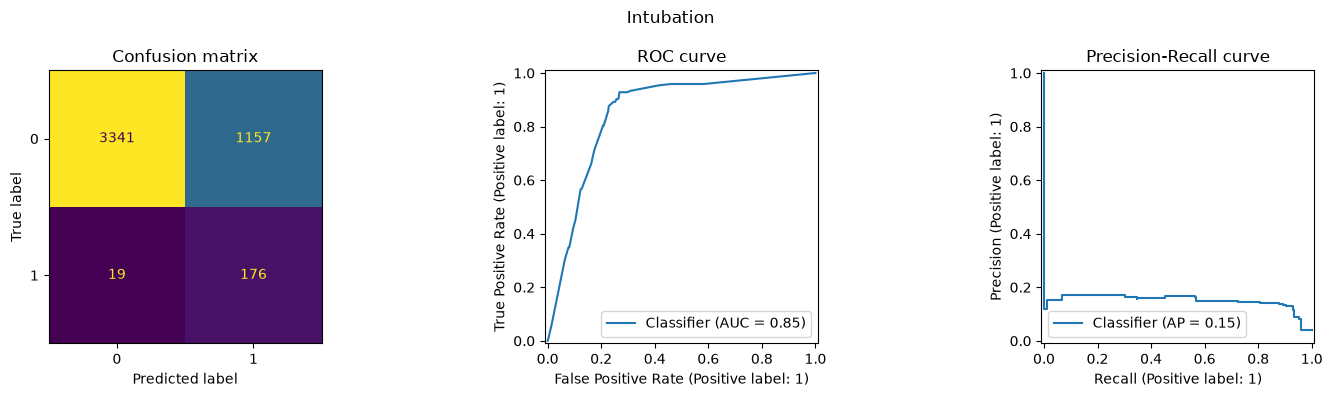


 ************************* Results for Death Prediction Model *************************
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      4266
           1       0.23      0.81      0.35       427

    accuracy                           0.73      4693
   macro avg       0.60      0.77      0.59      4693
weighted avg       0.91      0.73      0.79      4693

ROC AUC: 0.839
Average precision (PR AUC): 0.298 (random baseline ~ 0.091)
Precision at recall >= 0.8: 0.229
Precision at recall >= 0.9: 0.176
Precision at recall >= 0.95: 0.166


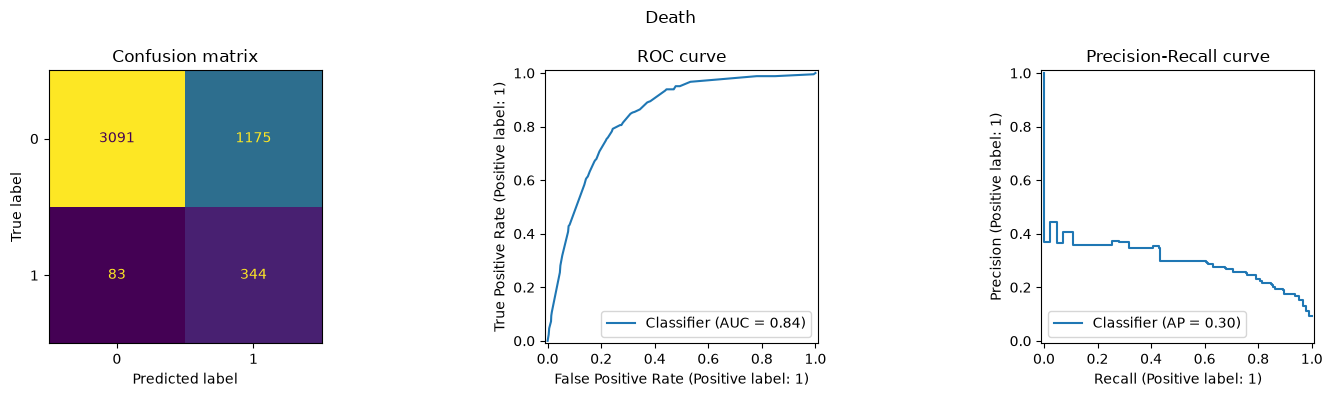

In [11]:
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import numpy as np


def precision_at_recall(y_true, scores, targets=(0.8, 0.9, 0.95)):
    """Best precision achievable while keeping recall >= each target."""
    precision, recall, _ = precision_recall_curve(y_true, scores)
    out = {}
    for t in targets:
        mask = recall >= t
        out[t] = precision[mask].max() if mask.any() else float("nan")
    return out


def evaluate(model, X_test, y_test, name):
    y_test = np.asarray(y_test).ravel()  # DataFrame/Series -> 1D array
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    print(f"\n {'*'*25} Results for {name} Prediction Model {'*'*25}")
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", round(roc_auc_score(y_test, y_score), 3))
    print("Average precision (PR AUC):", round(average_precision_score(y_test, y_score), 3),
          f"(random baseline ~ {y_test.mean():.3f})")
    for t, p in precision_at_recall(y_test, y_score).items():
        print(f"Precision at recall >= {t}: {p:.3f}")

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], colorbar=False)
    RocCurveDisplay.from_predictions(y_test, y_score, ax=ax[1])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax[2])
    ax[0].set_title("Confusion matrix")
    ax[1].set_title("ROC curve")
    ax[2].set_title("Precision-Recall curve")
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


evaluate(ICU_model,   X_ICU_test,   y_ICU_test,   "ICU")
evaluate(INT_model,   X_INT_test,   y_INT_test,   "Intubation")
evaluate(DEATH_model, X_DEATH_test, y_DEATH_test, "Death")

In [12]:
INPUT_DATA.columns


Index(['Age', 'Has_Pneumonia', 'Has_Diabetes', 'Has_COPD', 'Has_Asthma',
       'Is_Immunosuppressed', 'Has_Hypertension', 'Has_Cardiovascular',
       'Is_Smoker', 'Gender', 'Is_Obese'],
      dtype='str')

## Conclusion

All three models (logistic regression, SVM, decision tree) learned well to differentiate. ROC AUC is 0.79-0.87 across ICU, intubation and death, and average precision is about 3x the random baseline. With class weighting, they catch 80-90% of severe cases while ruling out 70-75% of patients (NPV 0.97-0.99), so they work as `screening filters`. A positive flag is only a weak indicator, since precision is 0.12-0.23, and the PR curves for ICU and intubation are flat. Death is the most predictable outcome.

**Precission-Recall Tradeoff**: As addressed by the paper, A high recall over precission is preffered as a False Negative is far more dangerous than False Positive for risk-classification model in the medical field.

**Best algorithm: logistic regression.** It matched or beat the others on every outcome (ICU AUC 0.82, intubation 0.866, death 0.844). It is also the simplest to explain and gives probabilities that can be calibrated. The decision tree is a close second (AUC 0.821, 0.856, 0.837), and the SVM is the weakest (0.786, 0.841, 0.801) as well as the slowest.

Because three different algorithms converge to similar results, the limit is the information in the features rather than the model. Richer inputs, such as the CT features in the original paper of Stanford, are the likeliest way to improve.